<a href="https://colab.research.google.com/github/MuhammadTalalZahid33/Waste-Classification-ML/blob/main/Waste_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys
import os

print("Python version:", sys.version)
print("Working directory:", os.getcwd())

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Working directory: /content


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
import kagglehub

path = kagglehub.dataset_download(
    "asdasdasasdas/garbage-classification"
)

print("Dataset path:", path)

100%|██████████| 82.0M/82.0M [00:00<00:00, 107MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2


In [5]:
import os

print("Files/folders inside dataset:")
print(os.listdir(path))

Files/folders inside dataset:
['one-indexed-files-notrash_val.txt', 'one-indexed-files.txt', 'one-indexed-files-notrash_train.txt', 'zero-indexed-files.txt', 'Garbage classification', 'one-indexed-files-notrash_test.txt', 'garbage classification']


In [6]:
from pathlib import Path

dataset_path = Path(path)

for item in dataset_path.rglob("*"):
    if item.is_dir():
        print("DIR :", item)

DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/Garbage classification
DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/garbage classification
DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/Garbage classification/Garbage classification
DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/garbage classification/Garbage classification
DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/garbage classification/Garbage classification/cardboard
DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/garbage classification/Garbage classification/metal
DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/garbage classification/Garbage classification/paper
DIR : /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/garbage classi

In [7]:
from pathlib import Path
from collections import Counter

dataset_path = Path(path)

# Locate the actual class directory
class_root = dataset_path / "Garbage classification" / "Garbage classification"

classes = sorted([
    p.name for p in class_root.iterdir()
    if p.is_dir()
])

print("Classes:")
for cls in classes:
    print(" -", cls)

print("\nImage counts:")

total = 0

for cls in classes:
    images = [
        p for p in (class_root / cls).iterdir()
        if p.is_file()
    ]

    print(f"{cls:10s}: {len(images):4d}")
    total += len(images)

print(f"\nTotal images: {total}")

Classes:
 - cardboard
 - glass
 - metal
 - paper
 - plastic
 - trash

Image counts:
cardboard :  403
glass     :  501
metal     :  410
paper     :  594
plastic   :  482
trash     :  137

Total images: 2527


In [8]:
split_files = [
    "zero-indexed-files.txt",
    "one-indexed-files.txt",
    "one-indexed-files-notrash_train.txt",
    "one-indexed-files-notrash_val.txt",
    "one-indexed-files-notrash_test.txt"
]

for filename in split_files:
    file_path = dataset_path / filename

    print("\n" + "=" * 60)
    print(filename)

    with open(file_path, "r", errors="ignore") as f:
        lines = f.readlines()

    print("Number of lines:", len(lines))
    print("First 5 entries:")

    for line in lines[:5]:
        print(repr(line.strip()))


zero-indexed-files.txt
Number of lines: 2527
First 5 entries:
'glass1.jpg 0'
'glass2.jpg 0'
'glass3.jpg 0'
'glass4.jpg 0'
'glass5.jpg 0'

one-indexed-files.txt
Number of lines: 2527
First 5 entries:
'glass1.jpg 1'
'glass2.jpg 1'
'glass3.jpg 1'
'glass4.jpg 1'
'glass5.jpg 1'

one-indexed-files-notrash_train.txt
Number of lines: 1768
First 5 entries:
'cardboard202.jpg 3'
'paper472.jpg 2'
'paper522.jpg 2'
'glass189.jpg 1'
'glass325.jpg 1'

one-indexed-files-notrash_val.txt
Number of lines: 328
First 5 entries:
'cardboard114.jpg 3'
'plastic204.jpg 4'
'glass123.jpg 1'
'glass152.jpg 1'
'glass398.jpg 1'

one-indexed-files-notrash_test.txt
Number of lines: 431
First 5 entries:
'paper70.jpg 2'
'paper380.jpg 2'
'cardboard31.jpg 3'
'glass12.jpg 1'
'paper169.jpg 2'


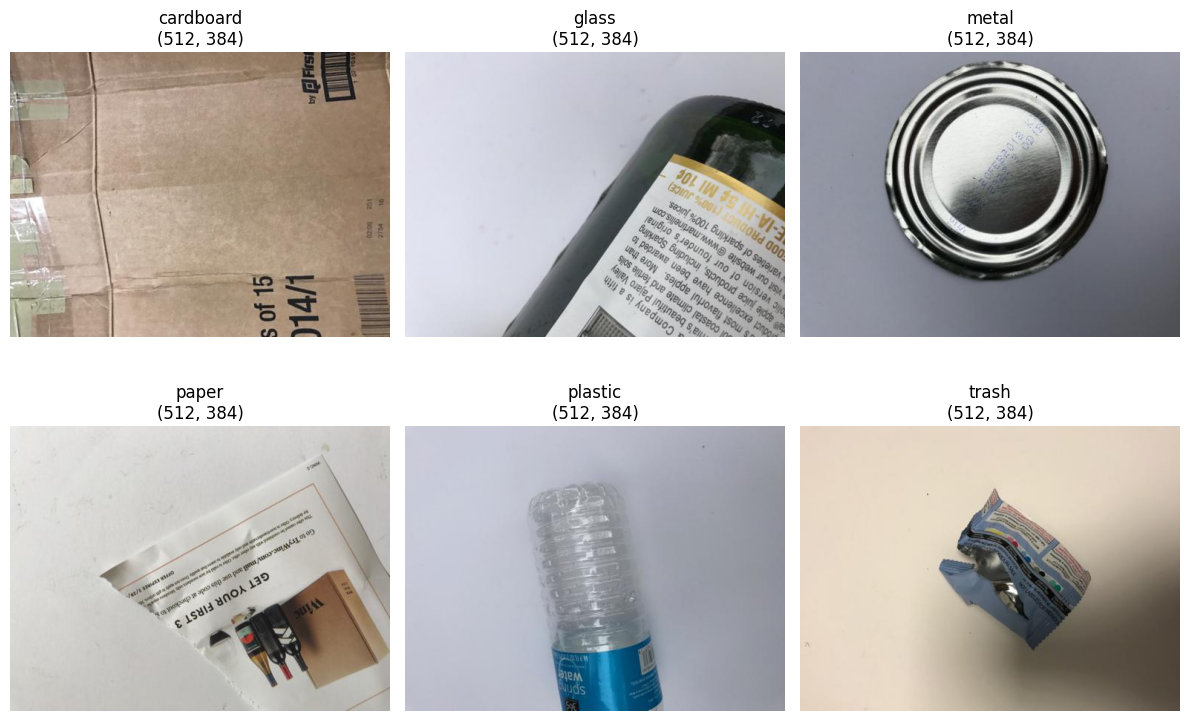

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, cls in zip(axes.flat, classes):
    class_dir = class_root / cls

    image_files = [
        p for p in class_dir.iterdir()
        if p.is_file()
    ]

    image_path = random.choice(image_files)
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(f"{cls}\n{image.size}")
    ax.axis("off")

plt.tight_layout()
plt.show()

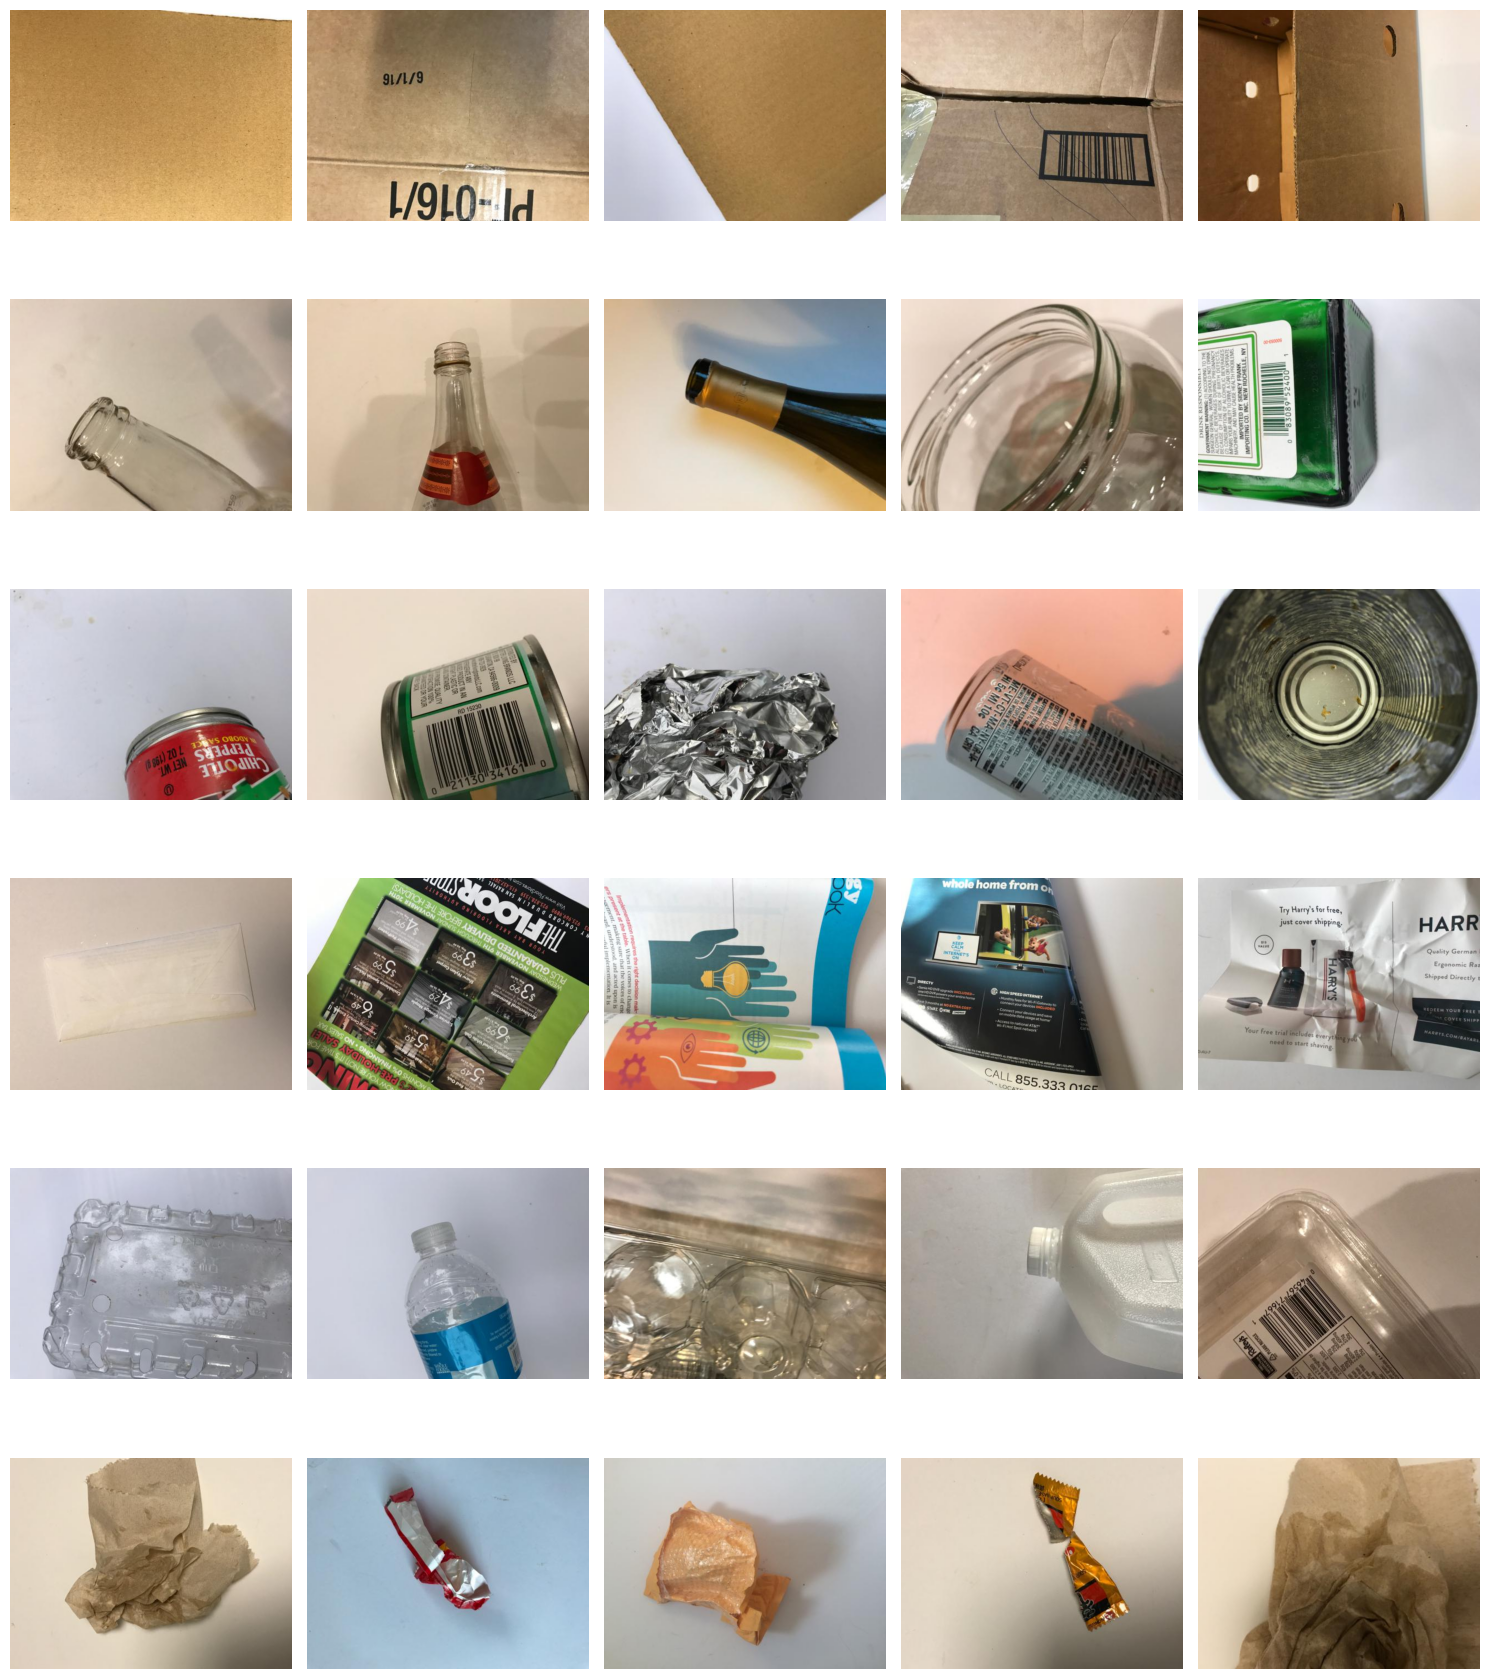

In [10]:
fig, axes = plt.subplots(
    len(classes),
    5,
    figsize=(15, 18)
)

for row, cls in enumerate(classes):
    class_dir = class_root / cls

    image_files = [
        p for p in class_dir.iterdir()
        if p.is_file()
    ]

    selected = random.sample(
        image_files,
        min(5, len(image_files))
    )

    for col, image_path in enumerate(selected):
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                cls,
                fontsize=12
            )

plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path
from collections import Counter

# Dataset locations
dataset_path = Path(path)
class_root = dataset_path / "Garbage classification" / "Garbage classification"

# Mapping used by the dataset's one-indexed files
label_to_class = {
    1: "glass",
    2: "paper",
    3: "cardboard",
    4: "plastic",
    5: "metal",
    6: "trash"
}

split_files = {
    "train": dataset_path / "one-indexed-files-notrash_train.txt",
    "validation": dataset_path / "one-indexed-files-notrash_val.txt",
    "test": dataset_path / "one-indexed-files-notrash_test.txt"
}


def read_split(file_path):
    samples = []

    with open(file_path, "r") as f:
        for line in f:
            filename, label = line.strip().split()

            samples.append({
                "filename": filename,
                "label": int(label),
                "class": label_to_class[int(label)]
            })

    return samples


splits = {
    name: read_split(file_path)
    for name, file_path in split_files.items()
}


# Print basic information
for split_name, samples in splits.items():
    print(f"\n{split_name.upper()}")
    print("-" * 40)
    print("Number of images:", len(samples))

    counts = Counter(sample["class"] for sample in samples)

    for cls in sorted(label_to_class.values()):
        print(f"{cls:10s}: {counts[cls]}")


TRAIN
----------------------------------------
Number of images: 1768
cardboard : 287
glass     : 354
metal     : 286
paper     : 403
plastic   : 347
trash     : 91

VALIDATION
----------------------------------------
Number of images: 328
cardboard : 46
glass     : 65
metal     : 56
paper     : 83
plastic   : 61
trash     : 17

TEST
----------------------------------------
Number of images: 431
cardboard : 70
glass     : 82
metal     : 68
paper     : 108
plastic   : 74
trash     : 29


In [12]:
# Check whether the splits overlap

train_files = {x["filename"] for x in splits["train"]}
val_files = {x["filename"] for x in splits["validation"]}
test_files = {x["filename"] for x in splits["test"]}

print("Train ∩ Validation:", len(train_files & val_files))
print("Train ∩ Test:      ", len(train_files & test_files))
print("Validation ∩ Test: ", len(val_files & test_files))

print()

all_split_files = train_files | val_files | test_files

actual_files = {
    p.name
    for cls in class_root.iterdir()
    if cls.is_dir()
    for p in cls.iterdir()
    if p.is_file()
}

print("Images in split files:", len(all_split_files))
print("Actual images:", len(actual_files))

print("Missing from splits:", len(actual_files - all_split_files))
print("Not found on disk:", len(all_split_files - actual_files))

Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0

Images in split files: 2527
Actual images: 2527
Missing from splits: 0
Not found on disk: 0


In [13]:
from PIL import Image
from collections import Counter

# Check that every split entry exists in the expected class folder
label_errors = []
image_info = []

for split_name, samples in splits.items():

    for sample in samples:
        filename = sample["filename"]
        expected_class = sample["class"]

        image_path = class_root / expected_class / filename

        if not image_path.exists():
            label_errors.append({
                "split": split_name,
                "filename": filename,
                "expected_class": expected_class,
                "path": str(image_path)
            })
            continue

        try:
            with Image.open(image_path) as img:
                image_info.append({
                    "split": split_name,
                    "filename": filename,
                    "class": expected_class,
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode
                })
        except Exception as e:
            label_errors.append({
                "split": split_name,
                "filename": filename,
                "error": str(e)
            })


print("Label/path errors:", len(label_errors))
print("Successfully read images:", len(image_info))

Label/path errors: 0
Successfully read images: 2527


In [14]:
import pandas as pd

df = pd.DataFrame(image_info)

print("Image modes:")
print(df["mode"].value_counts())

print("\nImage dimensions:")
print(df[["width", "height"]].describe())

print("\nUnique dimensions:", df[["width", "height"]].drop_duplicates().shape[0])

print("\nFirst 10 dimension combinations:")
print(
    df.groupby(["width", "height"])
      .size()
      .sort_values(ascending=False)
      .head(10)
)

Image modes:
mode
RGB    2527
Name: count, dtype: int64

Image dimensions:
        width  height
count  2527.0  2527.0
mean    512.0   384.0
std       0.0     0.0
min     512.0   384.0
25%     512.0   384.0
50%     512.0   384.0
75%     512.0   384.0
max     512.0   384.0

Unique dimensions: 1

First 10 dimension combinations:
width  height
512    384       2527
dtype: int64


In [15]:
print("\nImages per class and split:")
print(
    pd.crosstab(
        df["class"],
        df["split"]
    )
)


Images per class and split:
split      test  train  validation
class                             
cardboard    70    287          46
glass        82    354          65
metal        68    286          56
paper       108    403          83
plastic      74    347          61
trash        29     91          17


# **Build our PyTorch data pipeline**

In [16]:
import torch
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
from PIL import Image

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Device: cuda


In [17]:
class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(class_names)
}

idx_to_class = {
    idx: cls
    for cls, idx in class_to_idx.items()
}

print(class_to_idx)
print(idx_to_class)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}


In [18]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=15
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
class GarbageDataset(Dataset):

    def __init__(
        self,
        samples,
        root_dir,
        transform=None
    ):
        self.samples = samples
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        sample = self.samples[index]

        image_path = (
            self.root_dir
            / sample["class"]
            / sample["filename"]
        )

        image = Image.open(image_path).convert("RGB")

        label = class_to_idx[sample["class"]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [20]:
train_dataset = GarbageDataset(
    samples=splits["train"],
    root_dir=class_root,
    transform=train_transform
)

val_dataset = GarbageDataset(
    samples=splits["validation"],
    root_dir=class_root,
    transform=eval_transform
)

test_dataset = GarbageDataset(
    samples=splits["test"],
    root_dir=class_root,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1768
Validation: 328
Test: 431


In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [22]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("\nLabels:")
print(labels)

print("\nClass names:")
print([
    idx_to_class[label.item()]
    for label in labels
])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

Labels:
tensor([2, 4, 4, 0, 4, 4, 4, 0, 1, 3, 2, 0, 0, 4, 2, 3, 2, 3, 0, 4, 1, 4, 1, 3,
        0, 3, 4, 4, 1, 2, 3, 0])

Class names:
['metal', 'plastic', 'plastic', 'cardboard', 'plastic', 'plastic', 'plastic', 'cardboard', 'glass', 'paper', 'metal', 'cardboard', 'cardboard', 'plastic', 'metal', 'paper', 'metal', 'paper', 'cardboard', 'plastic', 'glass', 'plastic', 'glass', 'paper', 'cardboard', 'paper', 'plastic', 'plastic', 'glass', 'metal', 'paper', 'cardboard']


# **Verify Augmentations**

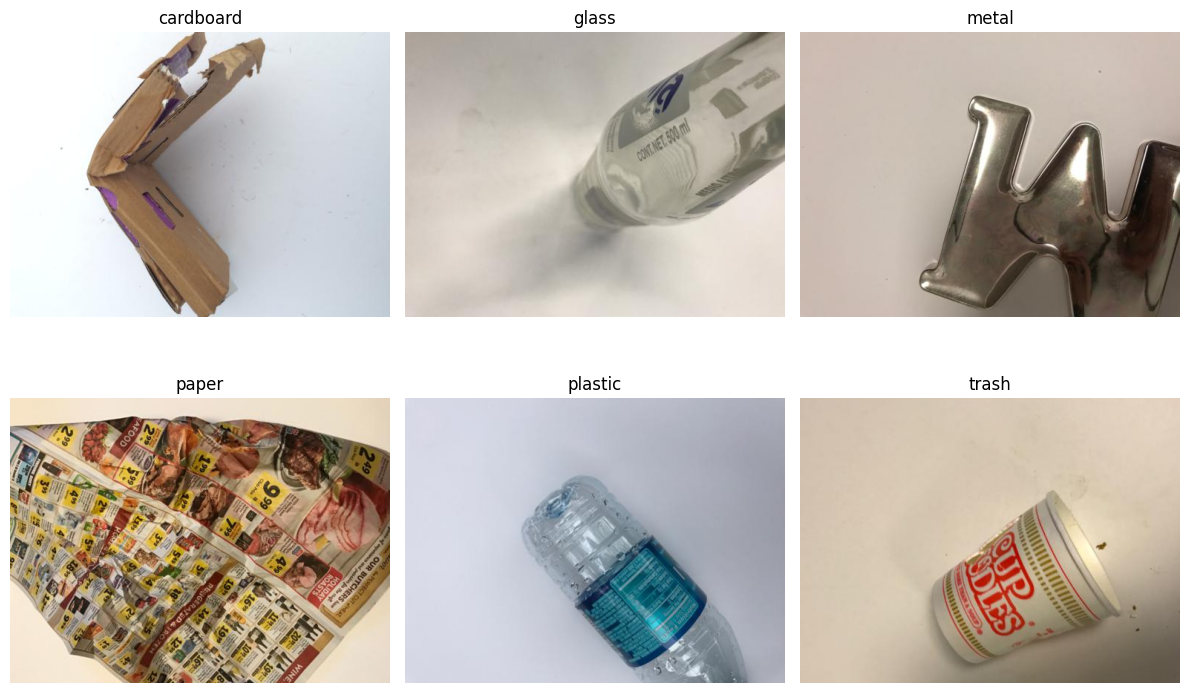

In [23]:
import matplotlib.pyplot as plt

# Get one original image from each class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, cls in zip(axes.flat, class_names):

    class_samples = [
        sample
        for sample in splits["train"]
        if sample["class"] == cls
    ]

    sample = class_samples[0]

    image_path = (
        class_root
        / sample["class"]
        / sample["filename"]
    )

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

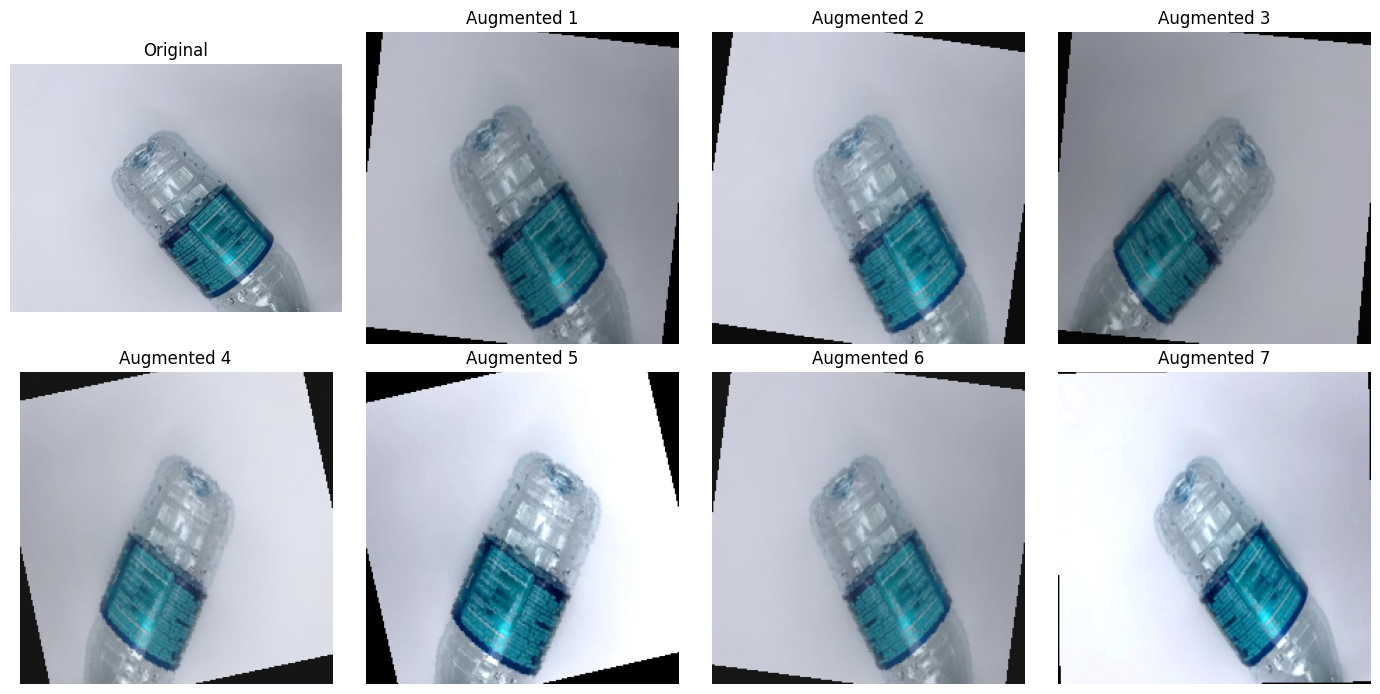

In [24]:
cls = "plastic"

sample = next(
    sample
    for sample in splits["train"]
    if sample["class"] == cls
)

image_path = (
    class_root
    / sample["class"]
    / sample["filename"]
)

original_image = Image.open(image_path).convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Original
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# Augmented versions
for i in range(7):

    augmented = train_transform(original_image)

    # Undo normalization so matplotlib can display it
    image = augmented.clone()

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean
    image = image.clamp(0, 1)

    row = (i + 1) // 4
    col = (i + 1) % 4

    axes[row, col].imshow(
        image.permute(1, 2, 0)
    )

    axes[row, col].set_title(
        f"Augmented {i + 1}"
    )

    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# **Establish a CNN baseline**

In [25]:
import torch
import torch.nn as nn


class WasteCNN(nn.Module):

    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 28 * 28,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = WasteCNN(
    num_classes=len(class_names)
).to(device)

print(model)

WasteCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [27]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     25,785,158
Trainable parameters: 25,785,158


In [28]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape: ", images.shape)
print("Output shape:", outputs.shape)

Input shape:  torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 6])


# **Training configuration**

Loss and **optimizer**

In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


**Create the training and validation functions**

In [30]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [31]:
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                (predictions == labels)
                .sum()
                .item()
            )

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

**Train the baseline**

In [32]:
import copy
import time

num_epochs = 20

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_state = None

for epoch in range(num_epochs):

    start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # Save the best validation model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] "
        f"| "
        f"Train Loss: {train_loss:.4f} "
        f"| "
        f"Train Acc: {train_accuracy:.4f} "
        f"| "
        f"Val Loss: {val_loss:.4f} "
        f"| "
        f"Val Acc: {val_accuracy:.4f} "
        f"| "
        f"Time: {elapsed:.1f}s"
    )

Epoch [01/20] | Train Loss: 1.7163 | Train Acc: 0.3077 | Val Loss: 1.6066 | Val Acc: 0.3323 | Time: 14.0s
Epoch [02/20] | Train Loss: 1.4452 | Train Acc: 0.4072 | Val Loss: 1.4414 | Val Acc: 0.4085 | Time: 14.2s
Epoch [03/20] | Train Loss: 1.3575 | Train Acc: 0.4615 | Val Loss: 1.3940 | Val Acc: 0.5061 | Time: 13.7s
Epoch [04/20] | Train Loss: 1.2475 | Train Acc: 0.5051 | Val Loss: 1.2963 | Val Acc: 0.5396 | Time: 13.6s
Epoch [05/20] | Train Loss: 1.1894 | Train Acc: 0.5515 | Val Loss: 1.2168 | Val Acc: 0.5610 | Time: 13.6s
Epoch [06/20] | Train Loss: 1.1397 | Train Acc: 0.5718 | Val Loss: 1.2690 | Val Acc: 0.5915 | Time: 13.5s
Epoch [07/20] | Train Loss: 1.0868 | Train Acc: 0.6029 | Val Loss: 1.2381 | Val Acc: 0.5549 | Time: 13.6s
Epoch [08/20] | Train Loss: 1.0769 | Train Acc: 0.6080 | Val Loss: 1.1926 | Val Acc: 0.5610 | Time: 13.7s
Epoch [09/20] | Train Loss: 1.0145 | Train Acc: 0.6171 | Val Loss: 1.1173 | Val Acc: 0.6037 | Time: 13.6s
Epoch [10/20] | Train Loss: 0.9901 | Train Acc

# **Visualize the learning curves**

**Ploting** what happened

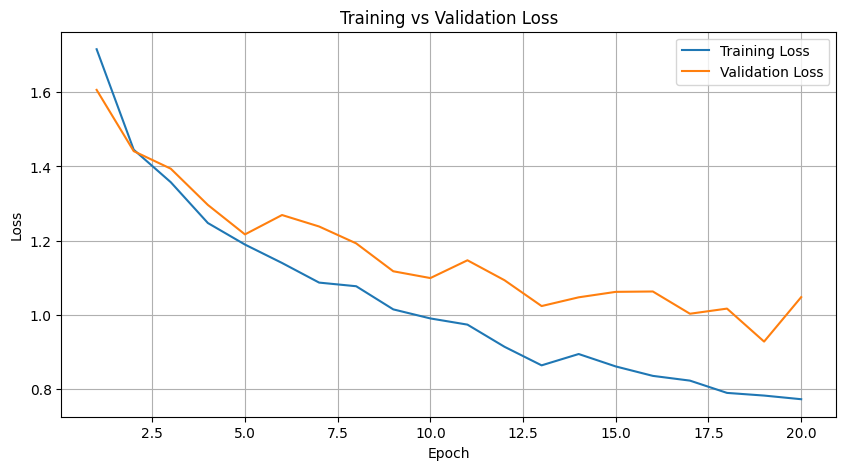

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

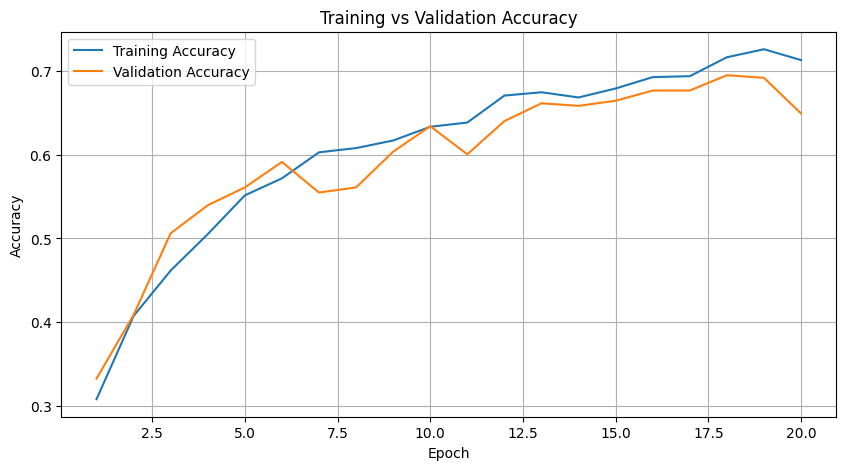

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# **Evaluate the baseline**

In [35]:
model.load_state_dict(best_model_state)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

Best validation accuracy: 0.6951


In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
import numpy as np

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu()

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("TEST SET RESULTS")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_labels,
        all_predictions
    )
)

TEST SET RESULTS
              precision    recall  f1-score   support

   cardboard     0.7108    0.8429    0.7712        70
       glass     0.6324    0.5244    0.5733        82
       metal     0.6750    0.3971    0.5000        68
       paper     0.6358    0.8889    0.7413       108
     plastic     0.6232    0.5811    0.6014        74
       trash     0.6500    0.4483    0.5306        29

    accuracy                         0.6520       431
   macro avg     0.6545    0.6138    0.6196       431
weighted avg     0.6523    0.6520    0.6379       431


Confusion Matrix:
[[59  2  0  6  1  2]
 [ 8 43  5  9 15  2]
 [ 8  7 27 21  4  1]
 [ 2  6  2 96  2  0]
 [ 2  7  4 16 43  2]
 [ 4  3  2  3  4 13]]


# **Build the stronger model, using ResNet18 Transfer learning**

In [37]:
from torchvision.models import (
    ResNet18_Weights,
    resnet18
)

weights = ResNet18_Weights.DEFAULT

transfer_model = resnet18(
    weights=weights
)

# Replace ImageNet's 1000-class classifier
transfer_model.fc = nn.Linear(
    transfer_model.fc.in_features,
    len(class_names)
)

transfer_model = transfer_model.to(device)

print(transfer_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [38]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    transfer_model.parameters(),
    lr=0.0001
)

print("Transfer-learning model ready.")

Transfer-learning model ready.


In [39]:
num_epochs = 10

transfer_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_transfer_accuracy = 0.0
best_transfer_state = None

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        transfer_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        transfer_model,
        val_loader,
        criterion,
        device
    )

    transfer_history["train_loss"].append(train_loss)
    transfer_history["train_accuracy"].append(train_accuracy)
    transfer_history["val_loss"].append(val_loss)
    transfer_history["val_accuracy"].append(val_accuracy)

    if val_accuracy > best_transfer_accuracy:
        best_transfer_accuracy = val_accuracy
        best_transfer_state = copy.deepcopy(
            transfer_model.state_dict()
        )

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

Epoch [01/10] | Train Loss: 0.8386 | Train Acc: 0.7014 | Val Loss: 0.5265 | Val Acc: 0.7896
Epoch [02/10] | Train Loss: 0.3607 | Train Acc: 0.8750 | Val Loss: 0.3721 | Val Acc: 0.8841
Epoch [03/10] | Train Loss: 0.2090 | Train Acc: 0.9367 | Val Loss: 0.3602 | Val Acc: 0.8659
Epoch [04/10] | Train Loss: 0.1522 | Train Acc: 0.9514 | Val Loss: 0.3776 | Val Acc: 0.8902
Epoch [05/10] | Train Loss: 0.1114 | Train Acc: 0.9678 | Val Loss: 0.3519 | Val Acc: 0.9055
Epoch [06/10] | Train Loss: 0.0944 | Train Acc: 0.9745 | Val Loss: 0.3210 | Val Acc: 0.9024
Epoch [07/10] | Train Loss: 0.0778 | Train Acc: 0.9808 | Val Loss: 0.3234 | Val Acc: 0.9177
Epoch [08/10] | Train Loss: 0.0676 | Train Acc: 0.9819 | Val Loss: 0.4029 | Val Acc: 0.8780
Epoch [09/10] | Train Loss: 0.0419 | Train Acc: 0.9881 | Val Loss: 0.3341 | Val Acc: 0.9085
Epoch [10/10] | Train Loss: 0.0402 | Train Acc: 0.9893 | Val Loss: 0.2979 | Val Acc: 0.9207
